# One-loop Z2SSM $\leftrightarrow$ SMEFT Matching

In [1]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from copy import deepcopy
from matplotlib import pyplot as plt
from IPython.display import HTML
from matplotlib.backends.backend_pdf import PdfPages
import scipy
import iminuit

mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 600
mpl.rcParams["animation.embed_limit"] = 10*1024*1024  # 10 MB


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

## $\Lambda_{\text{NP}} = \mu_{S}$

In [2]:
import pickle
vev = 246.
Mh = 125.

BP_input_dir = "/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/scan_output/Z2SSM_scan_output"
# BP_input_dir = "."
BP_dicts_filename = f"{BP_input_dir}/Benchmark_Points_outliers_dicts.pkl"
# BP_dicts_filename = f"{BP_input_dir}/Z2SSM_Benchmark_Points_outliers_dicts.pkl"

with open(BP_dicts_filename, 'rb') as f:
    BPs = pickle.load(f)
    bp_kappas = BPs["kappas"]
    # bp_EWPOs = BPs["EWPOs"]
    bp_model_pars = BPs["model_pars"]
    bp_indices = BPs["indices"]

print("BP kappas:", bp_kappas)
# print("BP EWPOs:", bp_EWPOs)
print("BP model parameters:", bp_model_pars)
print("BP indices:", bp_indices)

mS = np.array([bp["mS"] for bp in bp_model_pars]); print("\nmS:", mS)
muS = np.array([bp["muS"] for bp in bp_model_pars]); print("\nmuS:", muS)
lamS = np.array([bp["lamS"] for bp in bp_model_pars]); print("\nlamS:", lamS)
lamSH = np.array([bp["lamSH"] for bp in bp_model_pars]); print("\nlamSH:", lamSH)
bp_lambdas = np.array([bp["lam"] for bp in bp_kappas]); print("\nBP lambdas (2L):", bp_lambdas)
bp_lambdas_1L = np.array([bp["lam1L"] for bp in bp_kappas]); print("\nBP lambdas (1L):", bp_lambdas_1L)

# Testing the relation between mS, muS, lamSH
mS_test = np.sqrt(muS**2 + 0.5*lamSH*vev**2); print("\nmS test (from muS, lamSH):", mS_test)
mS_diff = mS - mS_test; print("\nmS - mS test:", mS_diff)

# Initialize the Z2SSM matching class
Z2SSM = EFT_matching.Z2SSM(muS=muS, lamS=lamS, lamSH=lamSH)
# lamNP=1000 #GeV

# Getting the matched Wilson coefficients at the NP scale
lamNP_tex = r'\mu_{S}'; lamNP_str = 'muS'
lamNP_match = muS
matched_WCs = Z2SSM.get_coefficients(lamNP_match=lamNP_match)
print("\nMatched Wilson coefficients at lamNP = muS:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = Z2SSM.get_kappa_lambda_SMEFT_match(lamNP_match=lamNP_match)
print(f"\nMatched SMEFT kappa_lambda at lamNP = {lamNP_tex}:\n", matched_kappa_lambdas)
print("\nModel kappa_lambda predictions: ", bp_lambdas)


# sort_indices = np.arange(14)
# sort_indices = [3, 5, 7, 9, 11]
# sort_indices = [0, 1, 2, 4, 6, 8, 10, 12, 13, ]

# Sorting arrays according to their 2L kala Z2SSM prediction
sort_indices = np.argsort(bp_lambdas)
# sort_indices = np.array([0, 1, 2, 4])
print("\nSorting indices:", sort_indices)
main_BP_indices = [0, 1, 2, 4]
main_BP_new_indices = np.array([sort_indices.tolist().index(i) for i in main_BP_indices])
print("Main BP new indices:", main_BP_new_indices)

bp_lambdas = bp_lambdas[sort_indices]
bp_lambdas_1L = bp_lambdas_1L[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]
mS = mS[sort_indices]
muS = muS[sort_indices]
lamS = lamS[sort_indices]
lamSH = lamSH[sort_indices]
CH    = deepcopy(matched_WCs["CH"])    [sort_indices]
CHbox = deepcopy(matched_WCs["CHbox"]) [sort_indices]

BP kappas: [{'lam': 1.0643594459030925, 'kappaSingleHiggs': 0.997795157109014, 'lam1L': 1.0163047292403735, 'uu': 0.997795157109014, 'dd': 0.997795157109014, 'ss': 0.997795157109014, 'cc': 0.997795157109014, 'bb': 0.997795157109014, 'tt': 0.997795157109014, 'ee': 0.997795157109014, 'mumu': 0.997795157109014, 'tautau': 0.997795157109014, 'ZZ': 0.997795157109014, 'WW': 0.997795157109014, 'gamgam': 0.997795157109014, 'Zgam': 0.997795157109014, 'gg': 0.997795157109014, 'ZZ_0': 0.9980563471636651, 'ZZ_0_with_WFR': 0.9979539099793131, 'ZZ_0_no_BSM': 1.0002630443516598, 'ZZ_0_with_WFR_no_BSM': 1.0001608331788296, 'ZZ_240': 0.9983849781927755, 'ZZ_240_with_WFR': 0.9982825747303763, 'ZZ_240_no_BSM': 1.0005909506201627, 'ZZ_240_with_WFR_no_BSM': 1.000488772946644, 'ZZ_240_use_HEPfit_C1_values': 0.9983408359865786, 'ZZ_240_with_WFR_HEPfit_C1_values': 0.9982384279958877, 'ZZ_365': 0.9980039274452023, 'ZZ_365_with_WFR': 0.9979014848798298, 'ZZ_365_no_BSM': 1.0002107402832767, 'ZZ_365_with_WFR_no_BS

### $\kappa_\lambda$

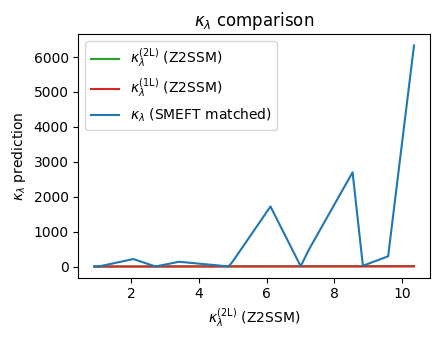

In [3]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, bp_lambdas_1L, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
ax.set_title(r'$\kappa_{\lambda}$ comparison')
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}.pdf")

### $\kappa_\lambda$ (Zoomed-in version)

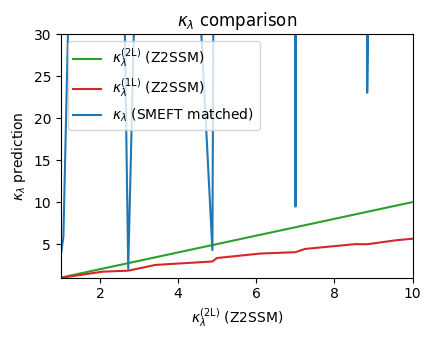

In [4]:
ax.set_xlim(1,10)
ax.set_ylim(1,30)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}_zoom.pdf")
fig

### Wilson coefficients

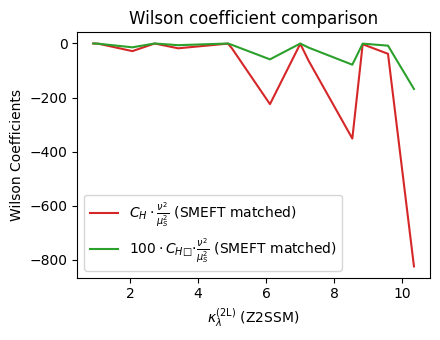

In [5]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 10*CHbox*vev**2, color='tab:green', label='$100\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.set_title(r'Wilson coefficient comparison')

ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison_lambda_matching_{lamNP_str}.pdf")

### Model parameters

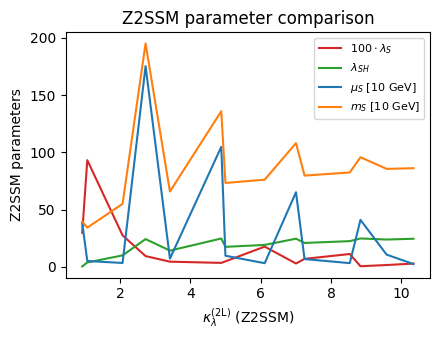

In [6]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, 100*lamS, color='tab:red', label=r'$100\cdot\lambda_{S}$')
ax.plot(bp_lambdas, lamSH, color='tab:green', label=r'$\lambda_{SH}$')
ax.plot(bp_lambdas, muS/10., color='tab:blue', label=r'$\mu_{S}$ [10 GeV]')
ax.plot(bp_lambdas, mS/10., color='tab:orange', label=r'$m_{S}$ [10 GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Z2SSM parameters')
ax.set_title(r'Z2SSM parameter comparison')
ax.legend(fontsize=8)
plt.tight_layout()

plt.savefig(f"{plot_dir}/Z2SSM_parameters_matching_comparison.pdf")

# Comparison with fitted values

In [7]:
model = "Z2SSM"
working_dir = "."

all_scenarios = [f"{model}_FCCee240_FCCee365"]

specs = [
    # "fits_long",
    # "fits_full",
    # "fits_realistic_HL_LHC_WFR_kala2_input_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_realistic_HL_LHC_long",
    # "fits_realistic_HL_LHC_all_EW_mods_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_sqrt_s_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_sqrt_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_external_leg_small_priors_long",
    # "fits_realistic_HL_LHC_small_priors_long",
    # "fits_realistic_HL_LHC_no_quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
]

spec_labels_dict = {
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long" : "Original",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values \n(including decay rates)",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Fit results",
    # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long" : "Using HEPfit formulas",
}
spec_labels = list(spec_labels_dict.values())

model_specs = {f"{model}_FCCee240_FCCee365" : specs,}
scenario_titles_dict = {f"{model}_FCCee240_FCCee365" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$",}
scenario_titles = list(scenario_titles_dict.values())

model_specs_labels = {f"{model}_FCCee240_FCCee365" : spec_labels,}


results_dirs = specs
results_dir_compare = "matching_comparison"

BPs = []; BPOs = []; BPBs = []
BPBnews = ["BPBnew_0", "BPBnew_1", "BPBnew_2", "BPBnew_4", ]

BPs = BPs + BPOs + BPBs + BPBnews

BP_names = [f"BP {i}" for i in range(len(BPs))]

BP_lambdas_all = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    0.9197317035823376, # BPB_3
    4.996504503173265,  # BPB_4
    2.723103795696014,  # BPB_5
    6.114019817191308,  # BPB_6
    4.878015572616551,  # BPB_7
    7.24831645311373,   # BPB_8
    7.005268951781772,  # BPB_9
    8.535635929341407,  # BPB_10
    8.84021000223677,   # BPB_11
    9.584476423981522,  # BPB_12
    10.34814810189343,  # BPB_13
]

BP_lambdas_0124 = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    4.996504503173265,  # BPB_4
]

plot_titles = { 
    scenario : { 
        # spec : f"{scenario_titles_dict[scenario]} scenario \n{spec_labels_dict[spec]}" 
        spec : f"{spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
    } 
    for scenario in all_scenarios
}

In [8]:
scenarios = model_specs.keys()
files = {}
for BP in BPs:
    files[BP] = {}
    for scenario in scenarios:
        files[BP][scenario] = {}
        for model_spec in model_specs[scenario]:
            files[BP][scenario][model_spec] = f"{working_dir}/{BP}/{scenario}/results_{model_spec}/Observables/Statistics.txt"

correlation_matrices = parser.read_fit_results_dim6Ops_correlations(
    BPs=BPs,
    model_specs=model_specs,
    files=files,
)
print(correlation_matrices)

Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR

In [9]:
parameters, parameters_tex, central_values_obs, results = parser.read_fit_results_pars(
    BPs,
    model_specs,
    working_dir,
    scenarios,
    model,
)

# print(f"\nParameters: {parameters}")
# print(f"\nParameters (LaTeX): {parameters_tex}")
# print(f"\nCentral values of observables: {central_values_obs}")
print(f"\nFit results: {results}")
# print(model_specs)


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./BPBnew_0/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_1/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_2/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_4/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all

### Defining the $\chi^2$ function

In [10]:
def chi_square(values, means, std_devs, corr):
    """
    Calculate the quadratic chi-square statistic given values, means, standard deviations, and the correlation matrix.

    Parameters
    ----------
    values : array-like, shape (n, d)
        The observed values.
    means : array-like, shape (d,)
        The expected mean values.
    std_devs : array-like, shape (d,)
        The standard deviations of the variables.
    corr : array-like, shape (d, d)
        The correlation matrix.

    Returns
    -------
    chi2 : float
        The calculated chi-square statistic.
    """
    one_eval = (values.ndim == 1)

    diff = np.atleast_2d(values) - means       # shape (n, d)
    cov = corr * np.outer(std_devs, std_devs)  # shape (d, d)
    inv_cov = np.linalg.inv(cov)               # shape (d, d)

    chi2 = np.sum((diff @ inv_cov) * diff, axis=1)    # shape (n,)
    return chi2[0] if one_eval else chi2

In [11]:
def confidence_level(nsigma):
    r"""Return the confidence level corresponding to a number of sigmas,
    i.e. the probability contained in the normal distribution between $-n\sigma$
    and $+n\sigma$.

    Example: `confidence_level(1)` returns approximately 0.68."""
    return (scipy.stats.norm.cdf(nsigma)-0.5)*2

def delta_chi2(nsigma, dof):
    r"""Compute the $\Delta\chi^2$ for `dof` degrees of freedom corresponding
    to `nsigma` Gaussian standard deviations.

    Example: For `dof=2` and `nsigma=1`, the result is roughly 2.3."""
    if dof == 1:
        # that's trivial
        return nsigma**2
    chi2_ndof = scipy.stats.chi2(dof)
    cl_nsigma = confidence_level(nsigma)
    return chi2_ndof.ppf(cl_nsigma)

def chi2_prob(chi2, dof):
    r"""Compute the probability that the chi2 value is equal or larger than `chi2'
    for `dof' degrees of freedom"""
    chi2_ndof = scipy.stats.chi2(dof)
    return 1 - chi2_ndof.cdf(chi2)

def chi2_prob_sigma(chi2, dof):
    r"""Convert a chi2 value with `dof` degrees of freedom to the equivalent
    number of Gaussian standard deviations."""
    chisq_probability = 1 - chi2_prob(chi2, dof)
    chi2_1D = scipy.stats.chi2(1)
    return np.sqrt(chi2_1D.ppf(chisq_probability))

def chi2_to_sigma(chi2, dof):
    r"""Convert a chi2 value with `dof` degrees of freedom to the equivalent
    number of Gaussian standard deviations."""
    chi2_ndof = scipy.stats.chi2(dof)
    survival_probability = chi2_ndof.sf(chi2)
    sigma = scipy.stats.norm.isf(survival_probability / 2)
    return sigma

# print("delta_chi2(nsigma=1, dof=1) =", delta_chi2(nsigma=1, dof=1))
# print("delta_chi2(nsigma=1, dof=2) =", delta_chi2(nsigma=1, dof=2))
# print("delta_chi2(nsigma=2, dof=2) =", delta_chi2(nsigma=2, dof=2))
# print("delta_chi2(nsigma=2, dof=2) =", delta_chi2(nsigma=3, dof=2))

# print("\nchi2_prob(2.295749, 2) =", chi2_prob(2.295749, 2))
# print(  "chi2_prob(6.180074, 2) =", chi2_prob(6.180074, 2))

# print("\nchi2_prob_sigma(6.180074306244173, 2) =", chi2_prob_sigma(6.180074306244173, 2))
# print(  "chi2_prob_sigma(11.829158081900795, 2) =", chi2_prob_sigma(11.829158081900795, 2))

# print(chi2_prob_sigma(64, 1))
# print(chi2_to_sigma(40**2, 1))

In [12]:
# print(chi_square(values=np.array([0,0]), means=np.array([1,2]), std_devs=np.array([10,1]), corr=np.array([[1,0],[0,1]])))

means    = np.array(results['BPBnew_0']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,0])
std_devs = np.array(results['BPBnew_0']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,1])
corr_matrix = correlation_matrices['BPBnew_0']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
values = np.full_like(means, 5e-4)
n_dof = len(means)

chi_square_value = chi_square(values=values, means=means, std_devs=std_devs, corr=corr_matrix)
significance = chi2_to_sigma(chi_square_value, n_dof)
print("means =", means)
print("std_devs =", std_devs)
print("corr_matrix =", corr_matrix)
print(f"χ² = {chi_square_value:.5g}")
print(f"n_dof = {n_dof}")
print(f"χ²/n_dof = {chi_square_value/n_dof:.5g}")
print(f"Significance = {significance:.3g} σ")

means = [ 8.30983433e-05  2.48197306e-04 -8.97170163e-04  7.71906848e-05
 -4.50572067e-04  4.90023544e-04 -2.83672376e-02  9.46437673e-05
  7.93506969e-05 -2.41755847e-04  1.70478178e-04  2.36307066e-04
  5.50613801e-04 -2.12242262e-04 -2.57712482e-04 -2.60451970e-04
  1.02985887e-03  4.95111534e-04  4.12861004e-04 -2.83526666e-04
 -6.46756061e-04 -2.04179720e-04  3.63135763e-05  1.16247335e-04
  1.59307933e-04  8.34128099e-02  3.22720161e-04 -4.10914797e-04
 -8.85574655e-02]
std_devs = [2.67886377e-03 1.00741289e-03 7.23121906e-03 2.11448300e-03
 3.91311566e-03 7.39773730e-03 4.72399704e-02 2.07787982e-03
 3.49974905e-03 3.48558057e-03 2.53519532e-03 4.65415050e-03
 4.57310000e-03 3.64940390e-03 3.78359230e-03 3.90961133e-03
 8.91629731e-03 4.81694276e-03 3.79937464e-03 4.95260254e-03
 2.09921193e-02 4.41094008e-03 4.28450833e-04 9.60615971e-04
 1.37669733e-03 2.96313357e-01 1.85106005e-03 3.37918376e-03
 8.54005826e-01]
corr_matrix = [[ 1.         0.0034904  0.0032771 -0.12638   -0.1

In [13]:
WC_means    = np.array(results['BPBnew_4']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,0])
WC_std_devs = np.array(results['BPBnew_4']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,1])
WC_corr_matrix = correlation_matrices['BPBnew_4']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
WC_names = parameters['BPBnew_4']['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
WC_names = [WC[:-5] if WC.endswith("_corr") else WC for WC in WC_names]
print(WC_names)
lamNP_fit = 1000 # GeV

def neg_2log_likelihood(muS, lamS, lamSH, lamNP_match, WC_means, WC_std_devs, WC_corr, WC_names, lamNP_fit=1000):
    Z2SSM = EFT_matching.Z2SSM(muS=muS, lamS=lamS, lamSH=lamSH)
    matched_WCs_dict = Z2SSM.get_coefficients(lamNP_match=lamNP_match)
    matched_WCs_array = np.array([np.atleast_1d(matched_WCs_dict[wc_name] * lamNP_fit**2) for wc_name in WC_names]).T
    # print("matched_WCs_array =", matched_WCs_array)
    chi2 = chi_square(values=matched_WCs_array, means=WC_means, std_devs=WC_std_devs, corr=WC_corr)
    return chi2

muS_test = 1000.0
lamS_test = 0.1
lamSH_test = 0.1
neg_LL = neg_2log_likelihood(
    muS=muS_test,
    lamS=lamS_test,
    lamSH=lamSH_test,
    lamNP_match=muS_test,
    WC_means=WC_means,
    WC_std_devs=WC_std_devs,
    WC_corr=WC_corr_matrix,
    WC_names=WC_names,
    lamNP_fit=1000,
)

n_dof = len(WC_means) - 3  # n of observables - n of fitted parameters
print(f"\nNegative log-likelihood at muS={muS_test}, lamS={lamS_test}, lamSH={lamSH_test}: {neg_LL}")
print(f"Corresponding significance: {chi2_to_sigma(2*neg_LL, n_dof)} σ")

['CW', 'CHG', 'CHW', 'CHB', 'CHWB', 'CHD', 'CHbox', 'CHL1_11', 'CHL1_22', 'CHL1_33', 'CHL3_11', 'CHL3_22', 'CHL3_33', 'CHe_11', 'CHe_22', 'CHe_33', 'CHQ1_11', 'CHQ1_33', 'CHQ3_11', 'CHu_11', 'CHd_11', 'CHd_33', 'CeH_22r', 'CeH_33r', 'CuH_22r', 'CuH_33r', 'CdH_33r', 'CLL_1221', 'CH']

Negative log-likelihood at muS=1000.0, lamS=0.1, lamSH=0.1: [445.70567447]
Corresponding significance: [27.88958329] σ


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.2025                     │              Nfcn = 77               │
│ EDM = 0.000102 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │   0.1e3   │   2.2e3   │            │            │    1    │  10000  │       │
│ 1 │ lamS  │   0.932   │   0.009   │            │            │    0    │   50    │  yes  │
│ 2 │ lamSH │     1     │    33     │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 7.54e+05        0   8.43e3 │
│  lamS │        0        0        0 │
│ lamSH │   8.43e3        0     94.4 │
└───────┴────────────────────────────┘

E MnContours unable to find first two points
Could not plot 1 sigma contour:


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/EFT_matching.py:256: RuntimeWarning: invalid value encountered in sqrt
  self.mS = np.sqrt(muS**2 + 0.5*lamSH*vev**2)


E MnContours unable to find first two points
Could not plot 3 sigma contour:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.084                      │              Nfcn = 134              │
│ EDM = 2.43e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │  0.46e3   │  0.12e3   │            │            │    1    │  10000  │       │
│ 1 │ lamS  │  0.2748   │  0.0028   │            │            │    0    │   50    │  yes  │
│ 2 │ lamSH │    9.3    │    2.3    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 1.45e+04        0      255 │
│  lamS │        0        0        0 │
│ lamSH │      255        0     5.52 │
└───────┴────────────────────────────┘

E MnContours unable to find first two points
Could not plot 3 sigma contour:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.117                      │              Nfcn = 108              │
│ EDM = 9.79e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │    530    │    100    │            │            │    1    │  10000  │       │
│ 1 │ lamS  │  44.6e-3  │  0.4e-3   │            │            │    0    │   50    │  yes  │
│ 2 │ lamSH │   13.5    │    2.1    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 9.09e+03      0e3      192 │
│  lamS │      0e3        0        0 │
│ lamSH │      192        0     4.44 │
└───────┴────────────────────────────┘

E MnContours unable to find second two points
Could not plot 3 sigma contour:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 14.29                      │              Nfcn = 103              │
│ EDM = 8.86e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │    500    │    80     │            │            │    1    │  10000  │       │
│ 1 │ lamS  │  47.3e-3  │  0.5e-3   │            │            │    0    │   50    │  yes  │
│ 2 │ lamSH │   15.4    │    2.1    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 7.03e+03      0e3      176 │
│  lamS │      0e3        0        0 │
│ lamSH │      176        0     4.48 │
└───────┴────────────────────────────┘

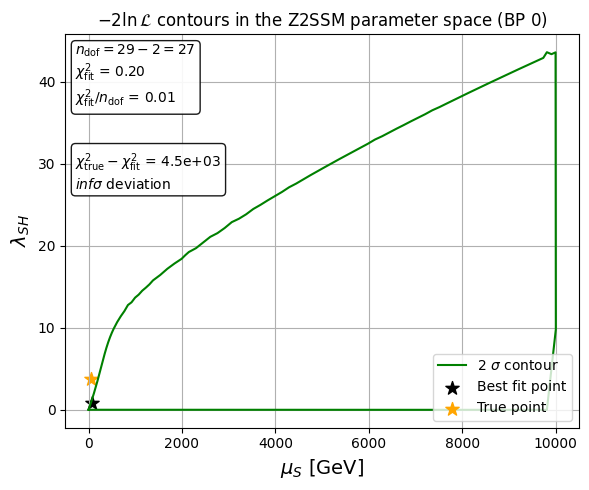

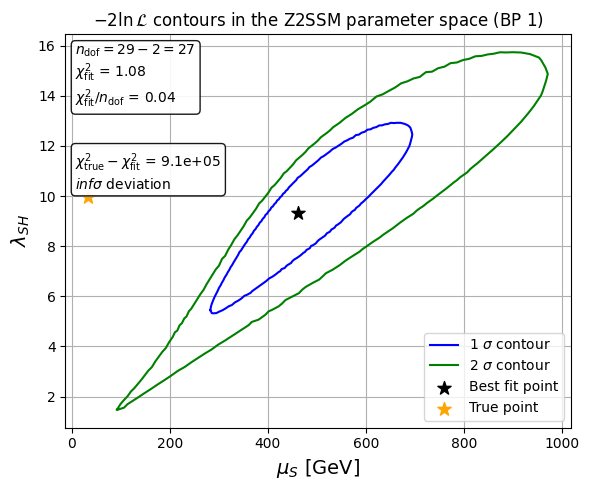

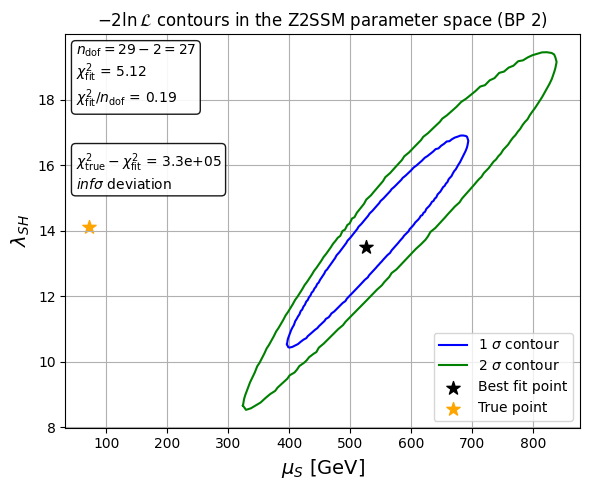

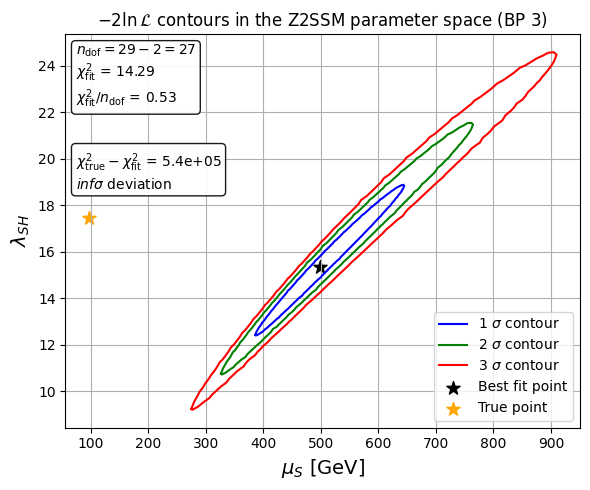

In [14]:
for i, (BP, BP_name) in enumerate(zip(main_BP_new_indices, BPBnews)):
    if i in []:
        # skipping the first two BPs, since they do not converge well
        continue

    muS_true = muS[BP]
    lamS_true = lamS[BP]
    lamSH_true = lamSH[BP]

    WC_means    = np.array(results[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,0])
    WC_std_devs = np.array(results[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,1])
    WC_corr_matrix = correlation_matrices[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
    WC_names = parameters[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
    WC_names = [WC[:-5] if WC.endswith("_corr") else WC for WC in WC_names]

    def iminuit_neg_LL(muS, lamS, lamSH):
        lamNP_match = muS
        return neg_2log_likelihood(
            muS=muS,
            lamS=lamS,
            lamSH=lamSH,
            lamNP_match=lamNP_match,
            WC_means=WC_means,
            WC_std_devs=WC_std_devs,
            WC_corr=WC_corr_matrix,
            WC_names=WC_names,
            lamNP_fit=1000,
        )

    m = iminuit.Minuit(
        iminuit_neg_LL,
        muS=muS_true, 
        lamS=lamS_true, 
        lamSH=lamSH_true, 
    )
    m.strategy = 1
    m.limits["muS"] = (1e0, 1e4)
    m.limits["lamS"] = (0.0, 50.0)
    m.limits["lamSH"] = (0.0, 50.0)
    m.fixed = [False, True, False]
    result = m.migrad()
    m.hesse()
    display(result) 

    contour_probs_123_sigma = [confidence_level(n_sigma) for n_sigma in [1, 2, 3]]
    color = ["blue", "green", "red"]
    fig, ax = plt.subplots(figsize=(6,5))
    for k, n_sigma in enumerate(range(1, 4)):
        try:
            pts = m.mncontour("muS", "lamSH", cl=contour_probs_123_sigma[k], size=200)
            x, y = np.transpose(pts)
            ax.plot(x, y, color=color[k], label=fr"{n_sigma} $\sigma$ contour")
        except ValueError:
            print(f"Could not plot {n_sigma} sigma contour:")

    (muS_fit, lamS_fit, lamSH_fit) = m.values
    ax.scatter(muS_fit, lamSH_fit, color='black', marker='*', s=100, label='Best fit point')
    ax.scatter(muS_true, lamSH_true, color='orange', marker='*', s=100, label='True point')

    n_WCs = len(WC_means)
    n_params = 2  # muS, lamSH (lamS fixed)
    n_dof = n_WCs - n_params
    ax.text(0.02, 0.98, 
        rf"$n_\mathrm{{dof}} = {n_WCs}-{n_params} = {n_dof}$""\n"+
        rf"$\chi^2_\mathrm{{fit}}$ = {m.fval:.2f}""\n"+
        rf"$\chi^2_\mathrm{{fit}}/n_\mathrm{{dof}}$ = {m.fval/n_dof:.2f}", 
        ha="left", va="top", transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'))

    chi2_true = iminuit_neg_LL(
        muS=muS_true,
        lamS=lamS_true,
        lamSH=lamSH_true,
    )[0]

    delta_chi2 = chi2_true - m.fval
    sigma_deviation = chi2_to_sigma(delta_chi2, dof=2)
    ax.text(0.02, 0.60, 
        rf"$\chi^2_\mathrm{{true}}-\chi^2_\mathrm{{fit}}$ = {delta_chi2:.2g}""\n"+
        rf"${sigma_deviation:.2g}\sigma$ deviation", #"\n"+
        # rf"$\chi^2_\mathrm{{true}}/n_\mathrm{{dof}}$ = {chi2_true/n_dof:.2g}", 
        ha="left", va="bottom", transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'))
    ax.set_xlabel(r'$\mu_{S}$ [GeV]', fontsize=14)
    ax.set_ylabel(r'$\lambda_{SH}$', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid()
    ax.set_title(rf'$-2\ln\mathcal{{L}}$ contours in the Z2SSM parameter space (BP {i})')
    fig.tight_layout()
    fig.savefig(f"{plot_dir}/Z2SSM_parameter_fit_contours_muS_lamSH_fixed_lamS_lambda_matching_{lamNP_str}_BP{i}.pdf")

# Pull plots

{'CH': array([-1.12142284e-05, -4.66822486e-04, -2.94818676e-04, -1.02928250e-10,
       -2.99944124e-04, -2.43906464e-06, -3.70604026e-03, -7.25225279e-06,
       -1.04650082e-03, -1.83998687e-05, -5.80766424e-03, -4.75770104e-05,
       -6.30723104e-04, -1.36201679e-02]), 'CHbox': array([-1.48227115e-06, -2.34350670e-05, -1.04350653e-05, -1.68188069e-10,
       -8.60325102e-06, -5.03566168e-08, -9.70307460e-05, -1.46724399e-07,
       -2.51163527e-05, -3.74824240e-07, -1.29603830e-04, -9.61681056e-07,
       -1.32463080e-05, -2.78113426e-04]), 'CW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHG': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWB': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gaga': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gagaorth': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

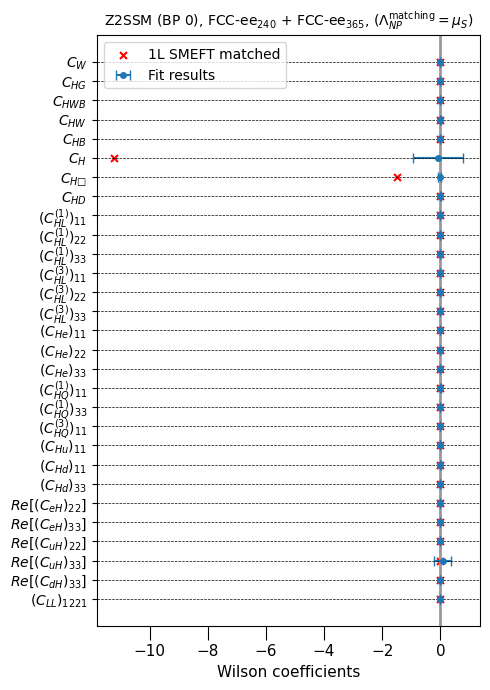

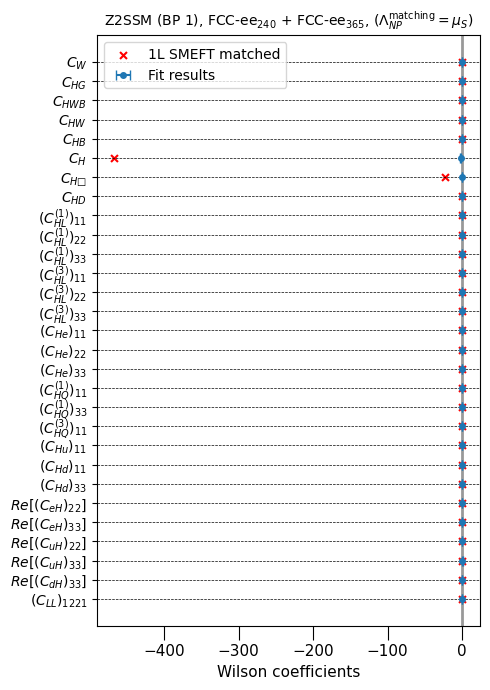

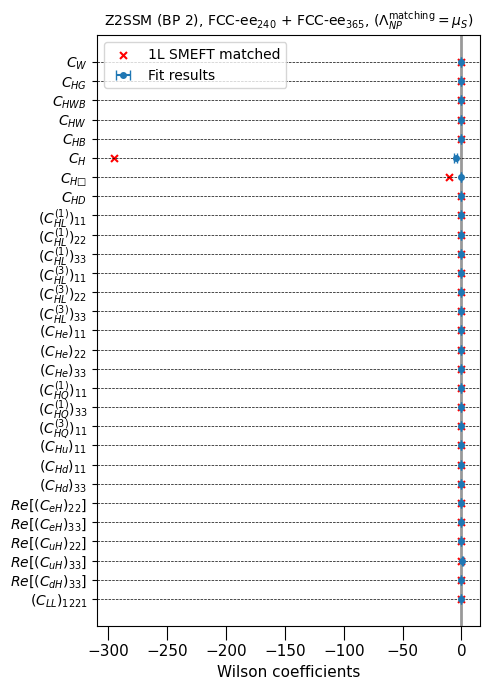

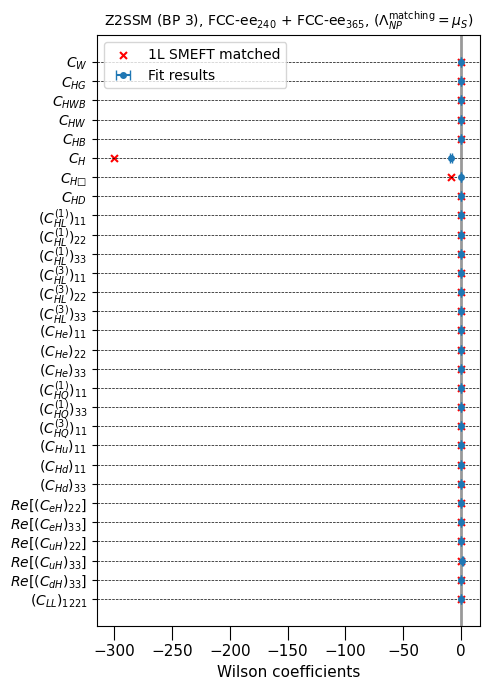

In [15]:
plot_titles = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}, "+r'($\Lambda_{NP}^\mathrm{matching}=$'rf'${lamNP_tex}$)'
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

print(matched_WCs)
lamNP_hepfit = 1000 #GeV
plotted_BPs = [0, 1, 2, 4]  # Indices of BPs to be plotted

matched_WCs_hepfit_compare = {wc : matched_WCs[wc][plotted_BPs] * (lamNP_hepfit)**2 for wc in matched_WCs.keys()}
print(matched_WCs_hepfit_compare)

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=False,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': False
    },
    file_suffix=f"_absolute_WCs_lambda_matching_{lamNP_str}",
)


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./BPBnew_0/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_1/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_2/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_4/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all

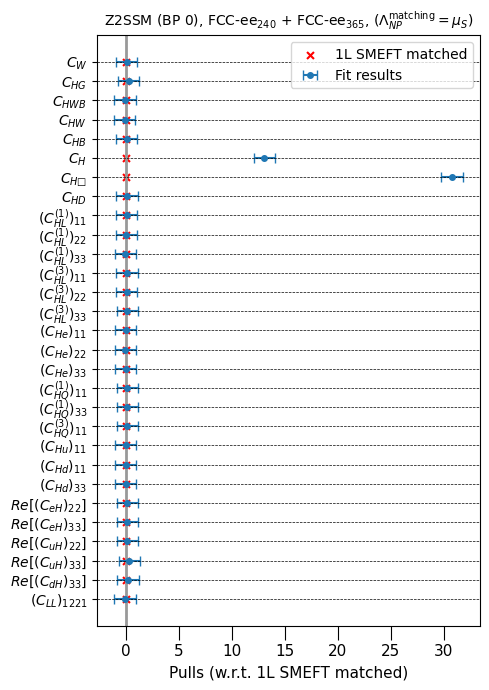

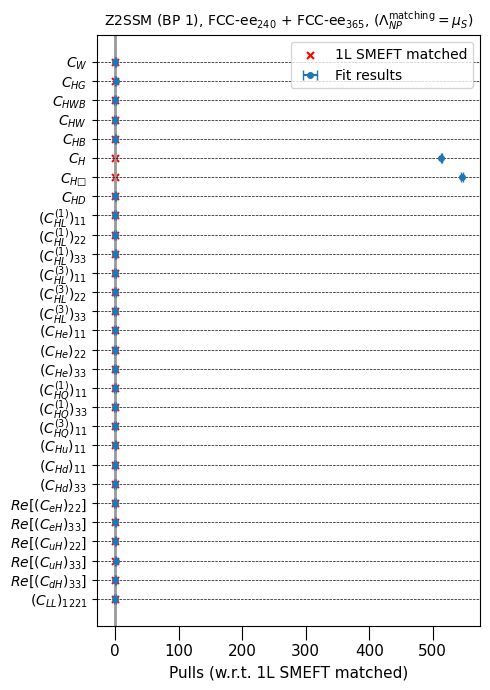

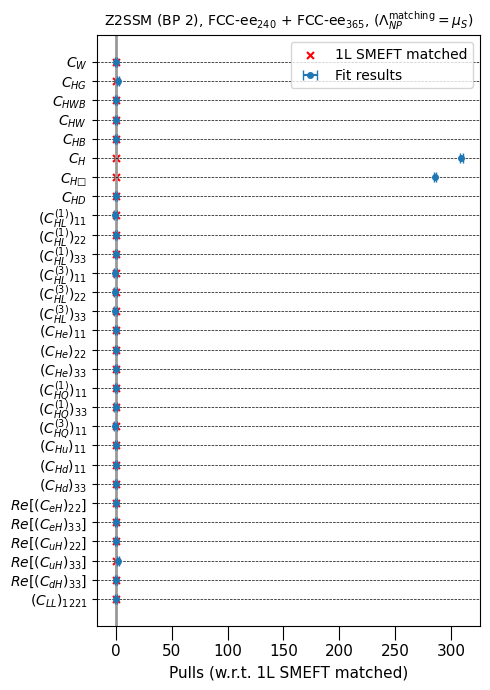

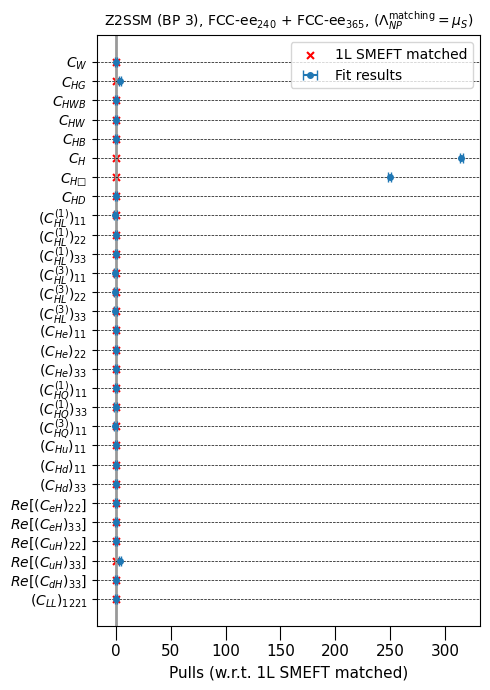

In [16]:

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=True,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': True
    },
    file_suffix=f"_WC_pulls_wrt_matched_absolute_WCs_lambda_matching_{lamNP_str}",
)

In [17]:
CH    = matched_WCs["CH"]    [plotted_BPs]
CHbox = matched_WCs["CHbox"] [plotted_BPs]


Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


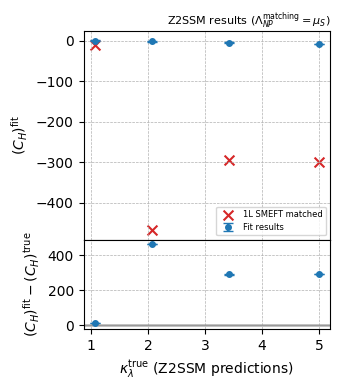


Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


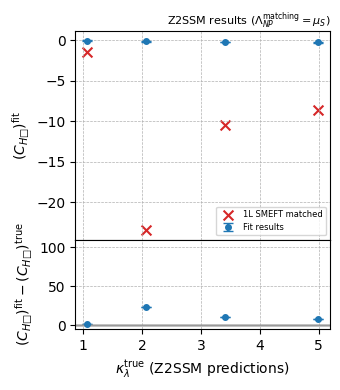

In [18]:

colors = ["tab:blue",]

utils.generate_obs_comparison_plot(
    observable='CH_corr',
    observable_label=r'(C_{H})',
    observable_text='CH',
    true_obs_values=CH*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)


utils.generate_obs_comparison_plot(
    observable='CHbox_corr',
    observable_label='(C_{H\u25A1})',
    observable_text='CHbox',
    true_obs_values=CHbox*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    y_lim_ax2=(-5, 110),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)

## $\Lambda_{\text{NP}} = m_{S}$

In [19]:
mS = np.array([bp["mS"] for bp in bp_model_pars])

# Getting the matched Wilson coefficients at the NP scale
lamNP_tex = r'm_{S}'; lamNP_str = 'mS'
lamNP_match = mS

matched_WCs = Z2SSM.get_coefficients(lamNP_match=lamNP_match)
print(f"\nMatched Wilson coefficients at lamNP = {lamNP_str}:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = Z2SSM.get_kappa_lambda_SMEFT_match(lamNP_match=lamNP_match)
print(f"\nMatched SMEFT kappa_lambda at lamNP = {lamNP_str}:\n", matched_kappa_lambdas)
print("\nModel kappa_lambda predictions: ", bp_lambdas)

mS = mS[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]
CH    = deepcopy(matched_WCs["CH"])    [sort_indices]
CHbox = deepcopy(matched_WCs["CHbox"]) [sort_indices]


Matched Wilson coefficients at lamNP = mS:
CH: [-2.44131250e-07 -1.72370676e-06 -3.43970870e-06 -9.68252204e-11
 -5.20772166e-06 -1.96945499e-06 -6.34973507e-06 -4.31470864e-06
 -7.51510104e-06 -6.68788368e-06 -8.74202265e-06 -8.71650342e-06
 -9.73268697e-06 -1.04492835e-05]
CHbox: [-3.22687122e-08 -8.65322142e-08 -1.21748003e-07 -1.58215523e-10
 -1.49372277e-07 -4.06611158e-08 -1.66247393e-07 -8.72932936e-08
 -1.80364816e-07 -1.36239065e-07 -1.95086970e-07 -1.76187956e-07
 -2.04403753e-07 -2.13366389e-07]
CW: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHG: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHWB: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHWHB_gaga: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHWHB_gagaorth: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHW: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHB: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHD: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHL1_11: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
CHL1_22: [0. 0. 0. 0. 0.

### $\kappa_\lambda$

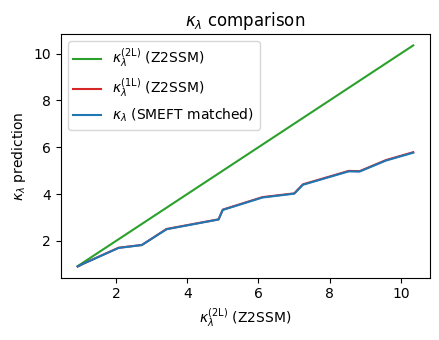

In [20]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, bp_lambdas_1L, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
ax.set_title(r'$\kappa_{\lambda}$ comparison')
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}.pdf")

### $\kappa_\lambda$ (Zoomed-in version)

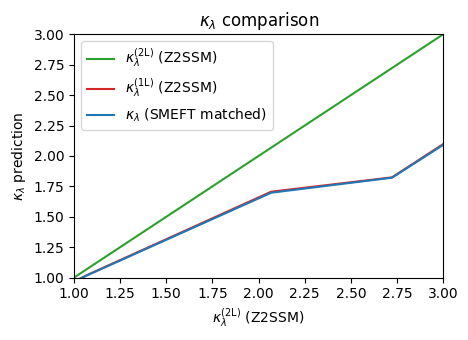

In [21]:
ax.set_xlim(1,3)
ax.set_ylim(1,3)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_lambda_matching_{lamNP_str}_zoom.pdf")
fig

### Wilson coefficients

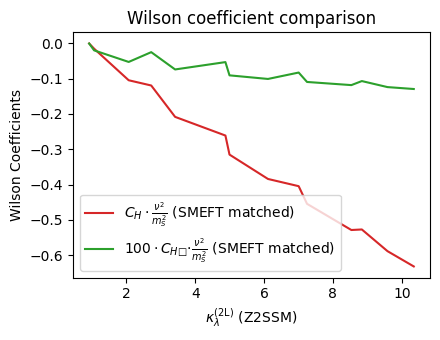

In [22]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 10*CHbox*vev**2, color='tab:green', label='$100\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.set_title(r'Wilson coefficient comparison')

ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison_lambda_matching_{lamNP_str}.pdf")

# Comparison with fitted values

In [23]:
scenarios = model_specs.keys()
files = {}
for BP in BPs:
    files[BP] = {}
    for scenario in scenarios:
        files[BP][scenario] = {}
        for model_spec in model_specs[scenario]:
            files[BP][scenario][model_spec] = f"{working_dir}/{BP}/{scenario}/results_{model_spec}/Observables/Statistics.txt"

correlation_matrices = parser.read_fit_results_dim6Ops_correlations(
    BPs=BPs,
    model_specs=model_specs,
    files=files,
)
print(correlation_matrices)

Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Found 29 observables in the correlation matrix


{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR

## Fit to model parameters

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.3755                     │              Nfcn = 42               │
│ EDM = 1.05e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │     0     │   0.5e3   │            │            │ -10000  │  10000  │       │
│ 1 │ lamS  │   0.932   │   0.009   │            │            │    0    │    5    │  yes  │
│ 2 │ lamSH │    3.9    │    2.7    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 2.11e+05        0       10 │
│  lamS │        0        0        0 │
│ lamSH │       10        0     7.48 │
└───────┴────────────────────────────┘

E MnContours unable to find first two points
Could not plot 2 sigma contour:
E MnContours unable to find first two points
Could not plot 3 sigma contour:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.777                      │              Nfcn = 41               │
│ EDM = 2.38e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │     0     │  0.26e3   │            │            │ -10000  │  10000  │       │
│ 1 │ lamS  │  0.2748   │  0.0028   │            │            │    0    │    5    │  yes  │
│ 2 │ lamSH │   10.6    │    1.8    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 6.98e+04        0      2.1 │
│  lamS │        0        0      0.0 │
│ lamSH │      2.1      0.0     3.35 │
└───────┴────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.006                      │              Nfcn = 51               │
│ EDM = 2.13e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │     0     │  0.19e3   │            │            │ -10000  │  10000  │       │
│ 1 │ lamS  │  44.6e-3  │  0.4e-3   │            │            │    0    │    5    │  yes  │
│ 2 │ lamSH │   16.9    │    1.2    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 3.71e+04        0      0.4 │
│  lamS │        0        0      0.0 │
│ lamSH │      0.4      0.0     1.43 │
└───────┴────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 22.98                      │              Nfcn = 59               │
│ EDM = 7.28e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ muS   │     0     │  0.16e3   │            │            │ -10000  │  10000  │       │
│ 1 │ lamS  │  47.3e-3  │  0.5e-3   │            │            │    0    │    5    │  yes  │
│ 2 │ lamSH │   22.7    │    0.7    │            │            │    0    │   50    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │      muS     lamS    lamSH │
├───────┼────────────────────────────┤
│   muS │ 2.67e+04        0      1.5 │
│  lamS │        0        0      0.0 │
│ lamSH │      1.5      0.0    0.495 │
└───────┴────────────────────────────┘

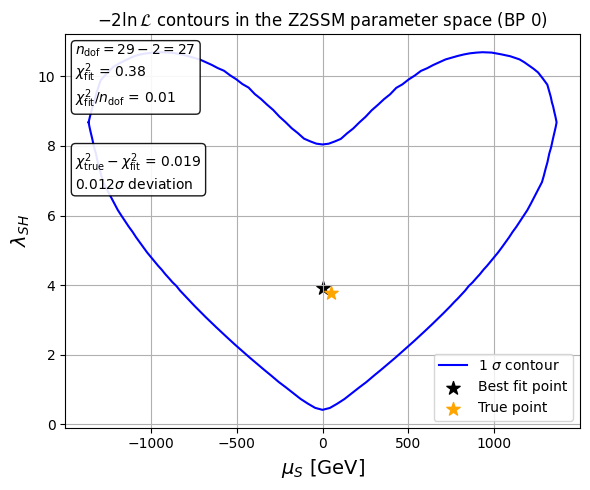

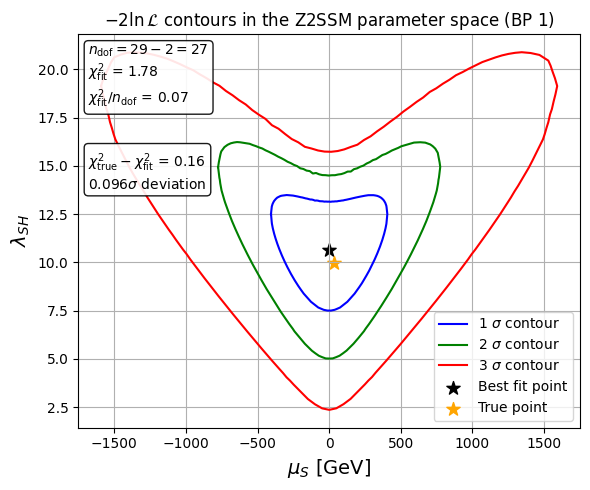

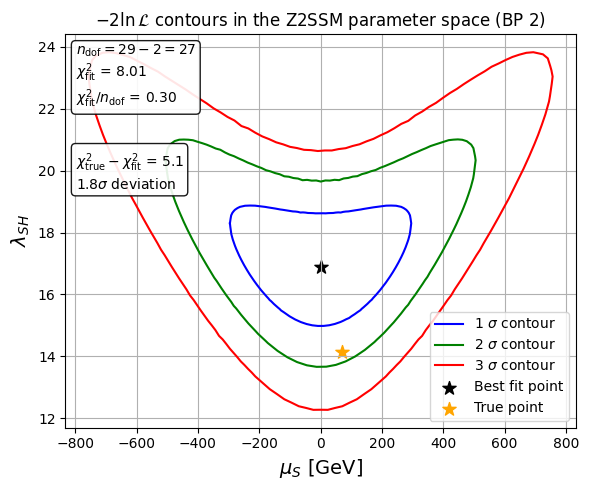

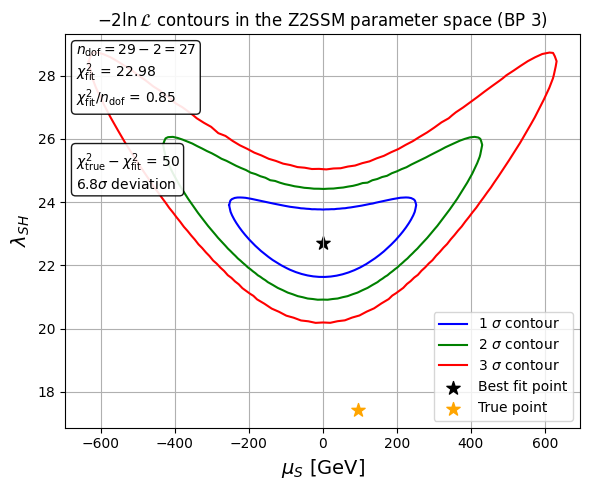

In [24]:
for i, (BP, BP_name) in enumerate(zip(main_BP_new_indices, BPBnews)):
    if i in []:
        # skipping the first BPs, since they do not converge well
        continue

    muS_true = muS[BP]
    lamS_true = lamS[BP]
    lamSH_true = lamSH[BP]

    WC_means    = np.array(results[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,0])
    WC_std_devs = np.array(results[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long'][:,1])
    WC_corr_matrix = correlation_matrices[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
    WC_names = parameters[BP_name]['Z2SSM_FCCee240_FCCee365']['fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long']
    WC_names = [WC[:-5] if WC.endswith("_corr") else WC for WC in WC_names]

    def iminuit_neg_LL(muS, lamS, lamSH):
        lamNP_match = np.sqrt(muS**2 + 0.5*lamSH*vev**2)  # mS
        return neg_2log_likelihood(
            muS=muS,
            lamS=lamS,
            lamSH=lamSH,
            lamNP_match=lamNP_match,
            WC_means=WC_means,
            WC_std_devs=WC_std_devs,
            WC_corr=WC_corr_matrix,
            WC_names=WC_names,
            lamNP_fit=1000,
        )

    m = iminuit.Minuit(
        iminuit_neg_LL,
        muS=muS_true, 
        lamS=lamS_true, 
        lamSH=lamSH_true, 
    )
    m.strategy = 1
    m.limits["muS"] = (-1e4, 1e4)
    m.limits["lamS"] = (0.0, 5.0)
    m.limits["lamSH"] = (0.0, 50.0)
    m.fixed = [False, True, False]
    result = m.migrad()
    m.hesse()
    display(result) 

    contour_probs_123_sigma = [confidence_level(n_sigma) for n_sigma in [1, 2, 3]]
    color = ["blue", "green", "red"]
    fig, ax = plt.subplots(figsize=(6,5))
    for k, n_sigma in enumerate(range(1, 4)):
        try:
            pts = m.mncontour("muS", "lamSH", cl=contour_probs_123_sigma[k], size=200)
            x, y = np.transpose(pts)
            ax.plot(x, y, color=color[k], label=fr"{n_sigma} $\sigma$ contour")
        except (ValueError, RuntimeError):
            print(f"Could not plot {n_sigma} sigma contour:")

    (muS_fit, lamS_fit, lamSH_fit) = m.values
    ax.scatter(muS_fit, lamSH_fit, color='black', marker='*', s=100, label='Best fit point')
    ax.scatter(muS_true, lamSH_true, color='orange', marker='*', s=100, label='True point')

    n_WCs = len(WC_means)
    n_params = 2  # muS, lamSH (lamS fixed)
    n_dof = n_WCs - n_params
    ax.text(0.02, 0.98, 
        rf"$n_\mathrm{{dof}} = {n_WCs}-{n_params} = {n_dof}$""\n"+
        rf"$\chi^2_\mathrm{{fit}}$ = {m.fval:.2f}""\n"+
        rf"$\chi^2_\mathrm{{fit}}/n_\mathrm{{dof}}$ = {m.fval/n_dof:.2f}", 
        ha="left", va="top", transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'))

    chi2_true = iminuit_neg_LL(
        muS=muS_true,
        lamS=lamS_true,
        lamSH=lamSH_true,
    )[0]

    delta_chi2 = chi2_true - m.fval
    sigma_deviation = chi2_to_sigma(delta_chi2, dof=2)
    ax.text(0.02, 0.60, 
        rf"$\chi^2_\mathrm{{true}}-\chi^2_\mathrm{{fit}}$ = {delta_chi2:.2g}""\n"+
        rf"${sigma_deviation:.2g}\sigma$ deviation", #"\n"+
        # rf"$\chi^2_\mathrm{{true}}/n_\mathrm{{dof}}$ = {chi2_true/n_dof:.2g}", 
        ha="left", va="bottom", transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'))
    ax.set_xlabel(r'$\mu_{S}$ [GeV]', fontsize=14)
    ax.set_ylabel(r'$\lambda_{SH}$', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid()
    ax.set_title(rf'$-2\ln\mathcal{{L}}$ contours in the Z2SSM parameter space (BP {i})')
    fig.tight_layout()
    fig.savefig(f"{plot_dir}/Z2SSM_parameter_fit_contours_muS_lamSH_fixed_lamS_lambda_matching_{lamNP_str}_BP{i}.pdf")

{'CH': array([-2.44131250e-07, -1.72370676e-06, -3.43970870e-06, -9.68252204e-11,
       -5.20772166e-06, -1.96945499e-06, -6.34973507e-06, -4.31470864e-06,
       -7.51510104e-06, -6.68788368e-06, -8.74202265e-06, -8.71650342e-06,
       -9.73268697e-06, -1.04492835e-05]), 'CHbox': array([-3.22687122e-08, -8.65322142e-08, -1.21748003e-07, -1.58215523e-10,
       -1.49372277e-07, -4.06611158e-08, -1.66247393e-07, -8.72932936e-08,
       -1.80364816e-07, -1.36239065e-07, -1.95086970e-07, -1.76187956e-07,
       -2.04403753e-07, -2.13366389e-07]), 'CW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHG': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWB': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gaga': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHWHB_gagaorth': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'CHW': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

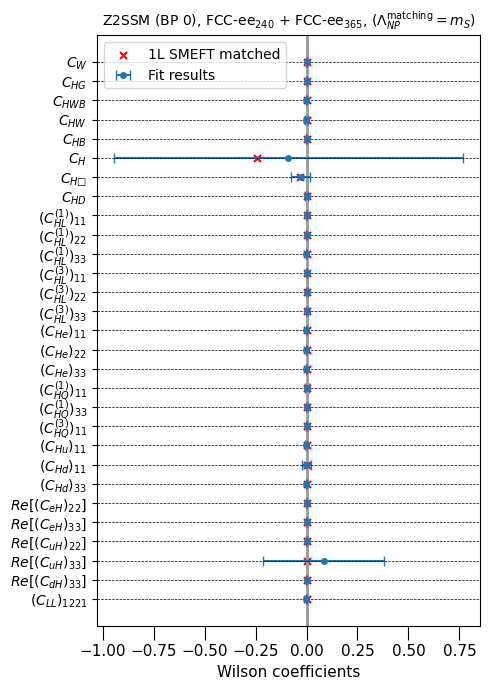

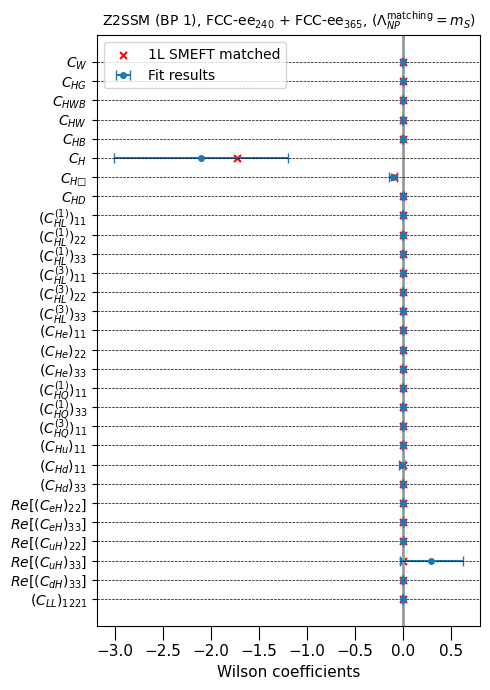

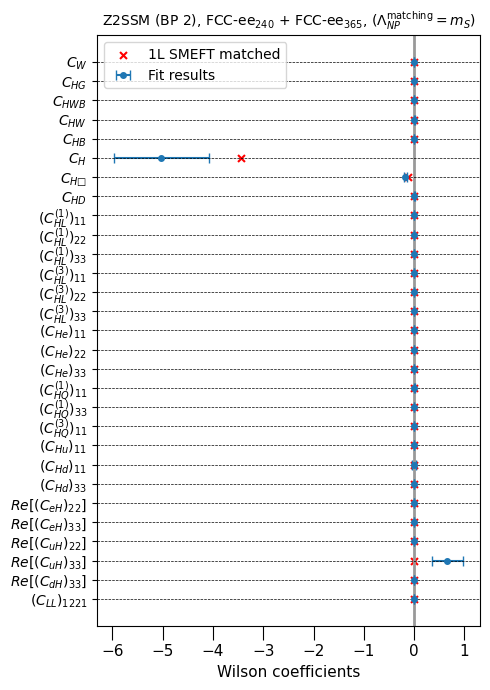

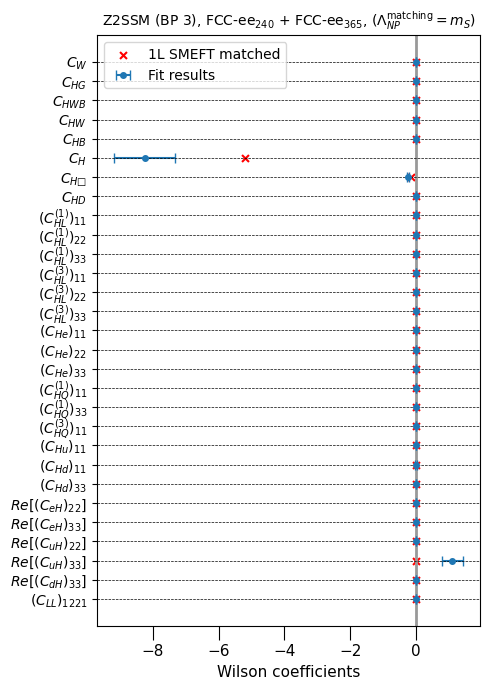

In [25]:
plot_titles = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}, "+r'($\Lambda_{NP}^\mathrm{matching}=$'rf'${lamNP_tex}$)'
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

print(matched_WCs)
lamNP_hepfit = 1000 #GeV
plotted_BPs = [0, 1, 2, 4]  # Indices of BPs to be plotted

matched_WCs_hepfit_compare = {wc : matched_WCs[wc][plotted_BPs] * (lamNP_hepfit)**2 for wc in matched_WCs.keys()}
print(matched_WCs_hepfit_compare)

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=False,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': False
    },
    file_suffix=f"_absolute_WCs_lambda_matching_{lamNP_str}",
)


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./BPBnew_0/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_1/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_2/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BPBnew_4/Z2SSM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'BPBnew_0': {'Z2SSM_FCCee240_FCCee365': {'fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all

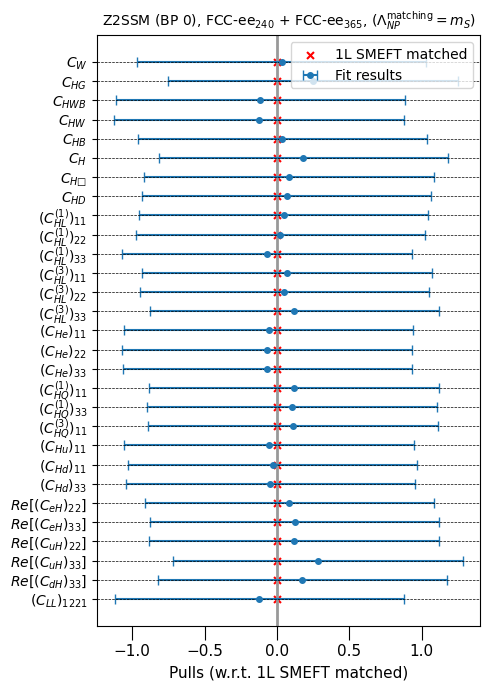

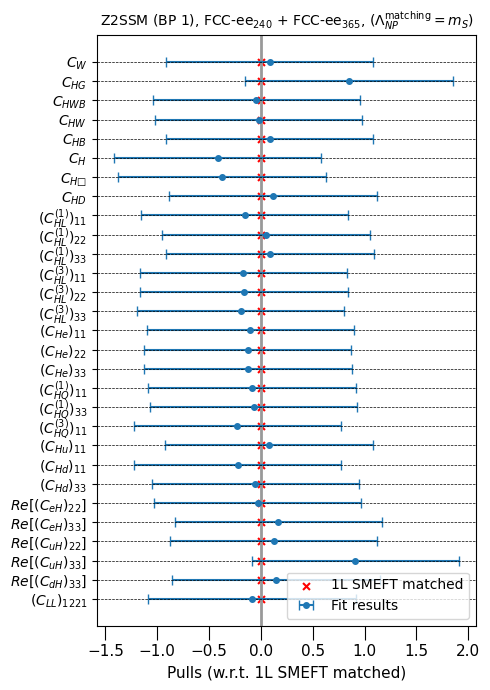

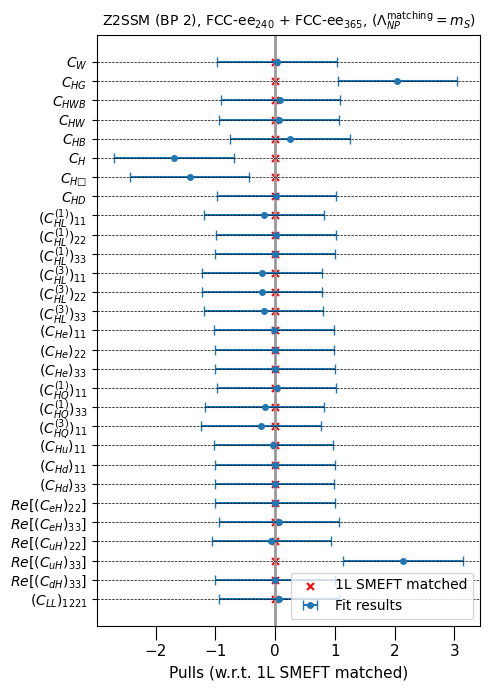

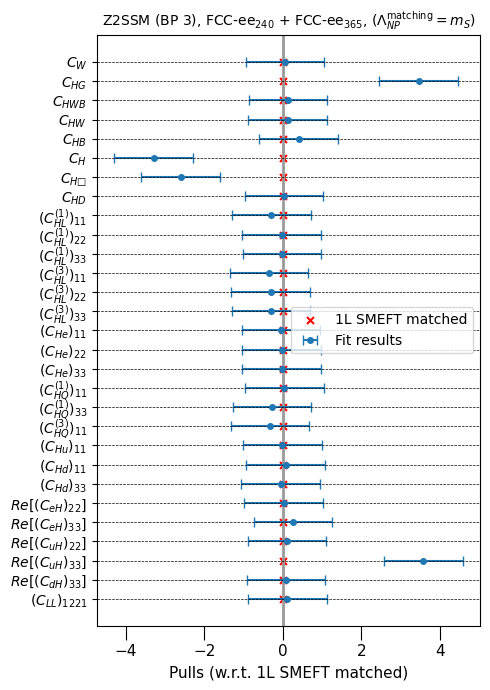

In [26]:

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
    normalize_pulls=True,
    true_values={
        'values': matched_WCs_hepfit_compare, 
        'label': '1L SMEFT matched', 
        'style': {'s': 25, 'marker': 'x', 'color': 'red'},
        'subtract_true_values': True
    },
    file_suffix=f"_WC_pulls_wrt_matched_absolute_WCs_lambda_matching_{lamNP_str}",
)

In [27]:
CH    = matched_WCs["CH"]    [plotted_BPs]
CHbox = matched_WCs["CHbox"] [plotted_BPs]

CH at mS matching: [-0.24413125 -1.72370676 -3.4397087  -5.20772166]

Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


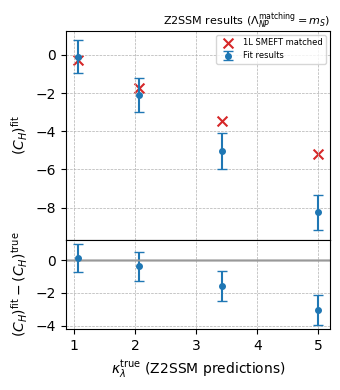


Reading fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt


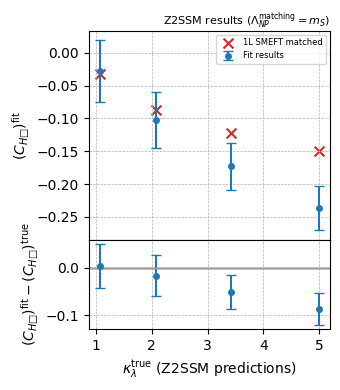

In [28]:
colors = ["tab:blue",]
print("CH at mS matching:", CH*lamNP_hepfit**2)


utils.generate_obs_comparison_plot(
    observable='CH_corr',
    observable_label=r'(C_{H})',
    observable_text='CH',
    true_obs_values=CH*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)


utils.generate_obs_comparison_plot(
    observable='CHbox_corr',
    observable_label='(C_{H\u25A1})',
    observable_text='CHbox',
    true_obs_values=CHbox*lamNP_hepfit**2,
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    plot_true_obs={"color": "tab:red", "s": 50, "label": "1L SMEFT matched"},
    # plot_true_obs=None,
    show_plots=True,
    # x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-5, 110),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    # upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    upper_right_text=rf"{model} results "+r'($\Lambda_{{NP}}^{{\mathrm{{matching}}}}=$'rf'${lamNP_tex}$)',
    file_suffix=f"_lambda_matching_{lamNP_str}",
)

In [29]:
raise RuntimeError("Do not run the following code; too time-consuming.")

RuntimeError: Do not run the following code; too time-consuming.

### Higgs potential (vs. SMEFT)

[[<matplotlib.lines.Line2D object at 0x14cf4a898460>, Text(0.5, 0.7, '$\\kappa_\\lambda=0.905$\n$C_H\\cdot\\frac{\\nu^2}{\\Lambda_{NP}^2}=-5.86e-06$'), <matplotlib.lines.Line2D object at 0x14cf4a898190>, <matplotlib.lines.Line2D object at 0x14cf4a8984c0>, <matplotlib.lines.Line2D object at 0x14cf4a898130>], [<matplotlib.lines.Line2D object at 0x14cf4abf6b20>, Text(0.5, 0.7, '$\\kappa_\\lambda=1.01$\n$C_H\\cdot\\frac{\\nu^2}{\\Lambda_{NP}^2}=-0.0148$'), <matplotlib.lines.Line2D object at 0x14cf4abf6550>, <matplotlib.lines.Line2D object at 0x14cf4abf64f0>, <matplotlib.lines.Line2D object at 0x14cf4abf62b0>], [<matplotlib.lines.Line2D object at 0x14cf4b9e33a0>, Text(0.5, 0.7, '$\\kappa_\\lambda=1.7$\n$C_H\\cdot\\frac{\\nu^2}{\\Lambda_{NP}^2}=-0.104$'), <matplotlib.lines.Line2D object at 0x14cf4b9e3040>, <matplotlib.lines.Line2D object at 0x14cf4a9a06d0>, <matplotlib.lines.Line2D object at 0x14cf4a9a0760>], [<matplotlib.lines.Line2D object at 0x14cf4ae17c70>, Text(0.5, 0.7, '$\\kappa_\\lam

MovieWriter ffmpeg unavailable; using Pillow instead.


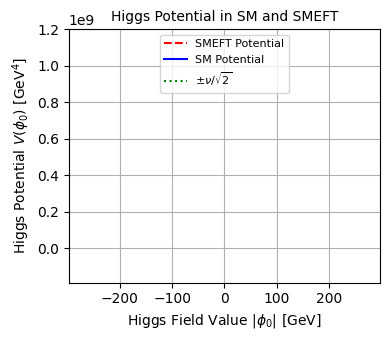

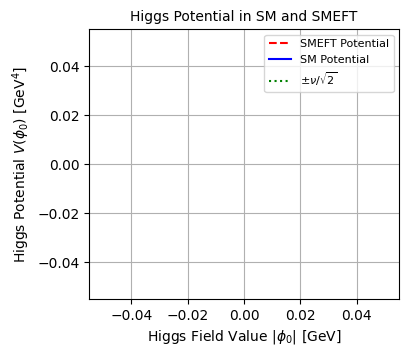

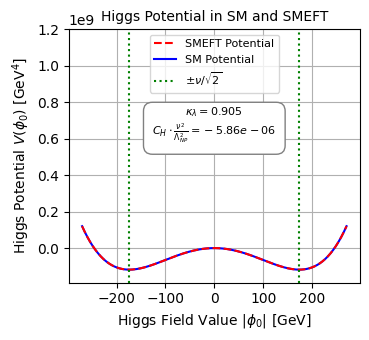

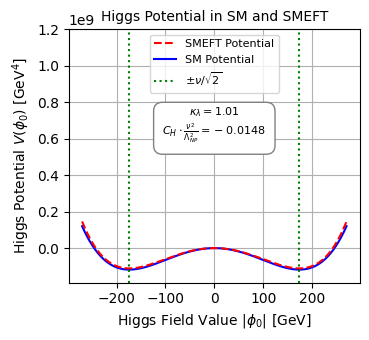

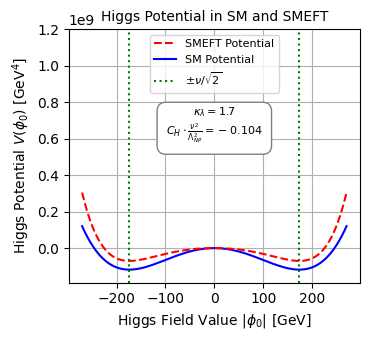

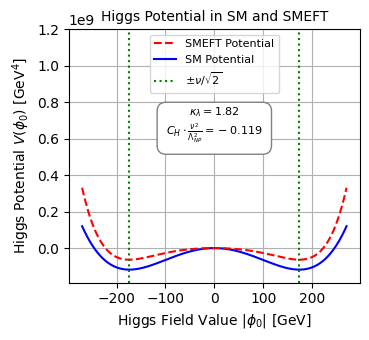

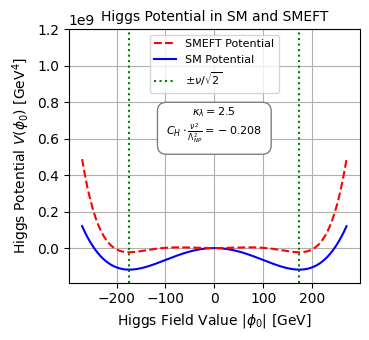

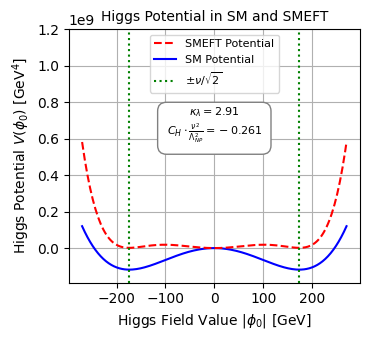

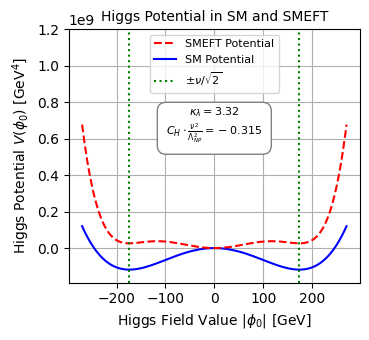

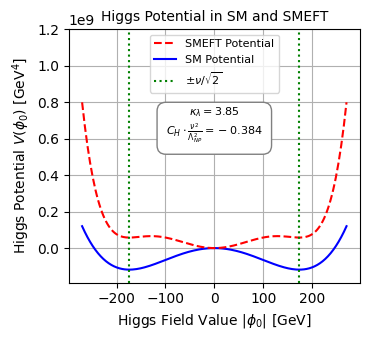

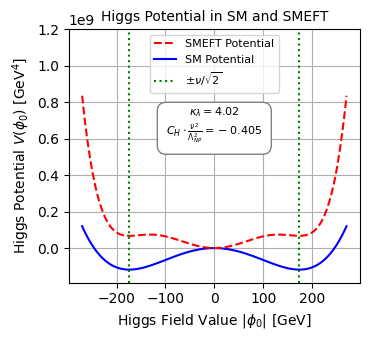

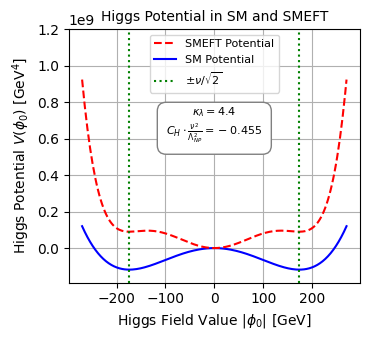

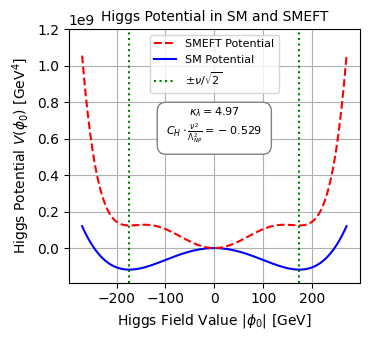

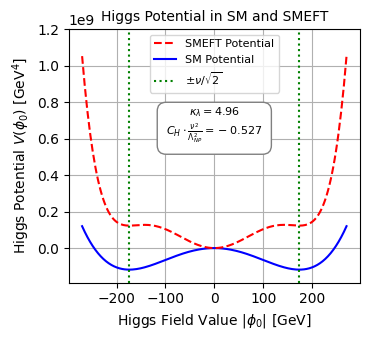

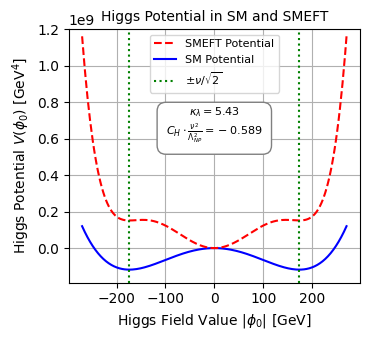

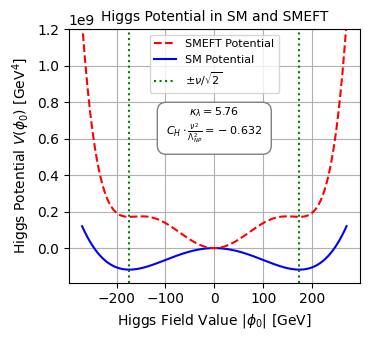

In [30]:
muS_test = muS[:]
lamS_test = lamS[:]
lamSH_test = lamSH[:]
mS_test = mS[:]
Z2SSM = EFT_matching.Z2SSM(muS=muS_test, lamS=lamS_test, lamSH=lamSH_test)
fig, ax, ani, frames = Z2SSM.plot_higgs_potential_SMEFT(lamNP_match=mS_test, animation=True, plot_dir=plot_dir, y_range=(-0.19e9, 1.2e9))
ani.save(f"{plot_dir}/Higgs_potential_SMEFT_matching_example.gif")
# fig.savefig(f"{plot_dir}/Higgs_potential_SMEFT_matching_example.pdf")

HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
# fig.show()

### Higgs potential (vs. Z2SSM)

In [31]:
kappa_lambda_SM = Z2SSM.kappa_lambda_SM
print(1-kappa_lambda_SM)

0.09455740816622926


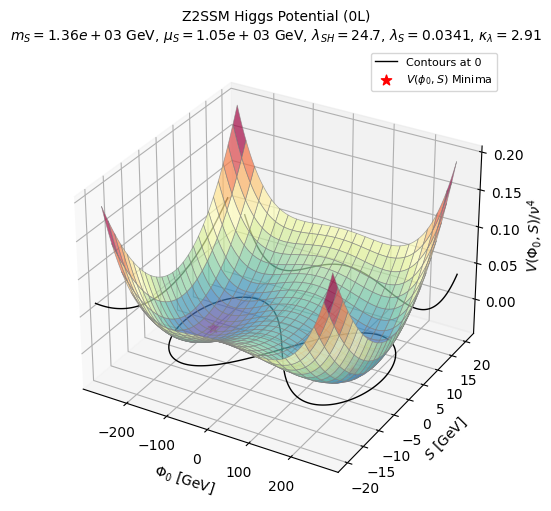

In [76]:
# BP_slice = [0, 1, 2, 3, 4, 5]
BP_slice = 5
muS_test = muS[BP_slice]
lamS_test = lamS[BP_slice]
lamSH_test = lamSH[BP_slice]
mS_test = mS[BP_slice]
Z2SSM = EFT_matching.Z2SSM(muS=muS_test, lamS=lamS_test, lamSH=lamSH_test)

animation_rotate=False
if not np.ndim(muS_test)==0:
    animation_parameter_points=True
else:
    animation_parameter_points=False
loop_order=["0L"]
loop_order_txt="0L"
fig, ax, ani = Z2SSM.plot_higgs_potential_Z2SSM(
    S_range=(-20, 20),
    plot_dir=plot_dir, 
    figsize=(6,5),
    n_frames=100,
    interval=100,
    animation_rotate=animation_rotate,
    plot_surface_kwargs={"0L": {"cmap": 'Spectral_r', 'alpha': 0.7, "lw":0.5, "edgecolor":"gray", "rstride":8, "cstride":8,}},
    x_contour={"colors": "black", "alpha": 1.0, "linewidths": 1., "levels":0,},
    y_contour={"colors": "black", "alpha": 1.0, "linewidths": 1., "levels":0,},
    z_contour={"colors": "black", "alpha": 1.0, "linewidths": 1., "levels":0,},
    plot_V_minima={"color": "red", "marker": "*", "s": 60,},
    loop_order=loop_order,
    loop_order_txt=loop_order_txt,
)
# fig, ax, ani, frames = Z2SSM.plot_higgs_potential_Z2SSM(animation=False, plot_dir=plot_dir)
if animation_rotate:
    HTML_anim = HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
    display(HTML_anim)
    ani.save(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM_rotate.gif")
elif animation_parameter_points:
    HTML_anim = HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
    display(HTML_anim)
    ani.save(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM_parameter_points.gif")
else:
    fig.savefig(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM.pdf")

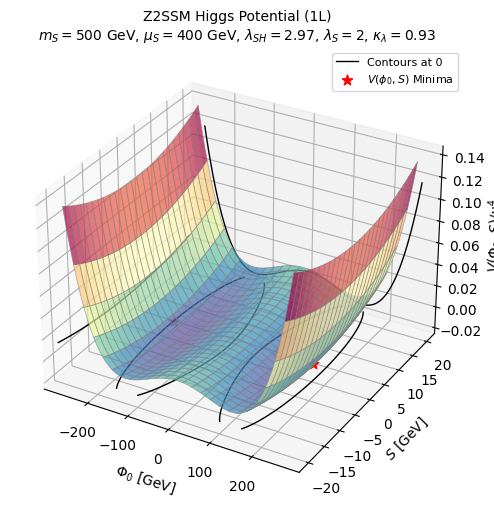

In [77]:
mS_test = 500
muS_test = 400
lamS_test = 2
lamSH_test = 2*(mS_test**2 - muS_test**2)/vev**2
Z2SSM = EFT_matching.Z2SSM(muS=muS_test, lamS=lamS_test, lamSH=lamSH_test)

animation_rotate=False
if not np.ndim(muS_test)==0:
    animation_parameter_points=True
else:
    animation_parameter_points=False
loop_order=["1L"]
loop_order_txt="1L"
fig, ax, ani = Z2SSM.plot_higgs_potential_Z2SSM(
    S_range=(-20, 20),
    plot_dir=plot_dir, 
    figsize=(6,5),
    n_frames=100,
    interval=100,
    animation_rotate=animation_rotate,
    plot_surface_kwargs={"1L": {"cmap": 'Spectral_r', 'alpha': 0.7, "lw":0.5, "edgecolor":"gray", "rstride":8, "cstride":8,}},
    x_contour={"colors": "black", "alpha": 1.0, "linewidths": 1., "levels":0,},
    y_contour={"colors": "black", "alpha": 1.0, "linewidths": 1., "levels":0,},
    z_contour={"colors": "black", "alpha": 1.0, "linewidths": 1., "levels":0,},
    plot_V_minima={"color": "red", "marker": "*", "s": 60,},
    loop_order=loop_order,
    loop_order_txt=loop_order_txt
)
# fig, ax, ani, frames = Z2SSM.plot_higgs_potential_Z2SSM(animation=False, plot_dir=plot_dir)
if animation_rotate:
    HTML_anim = HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
    display(HTML_anim)
    ani.save(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM_rotate.gif")
elif animation_parameter_points:
    HTML_anim = HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
    display(HTML_anim)
    ani.save(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM_parameter_points.gif")
else:
    fig.savefig(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM.pdf")

MovieWriter ffmpeg unavailable; using Pillow instead.


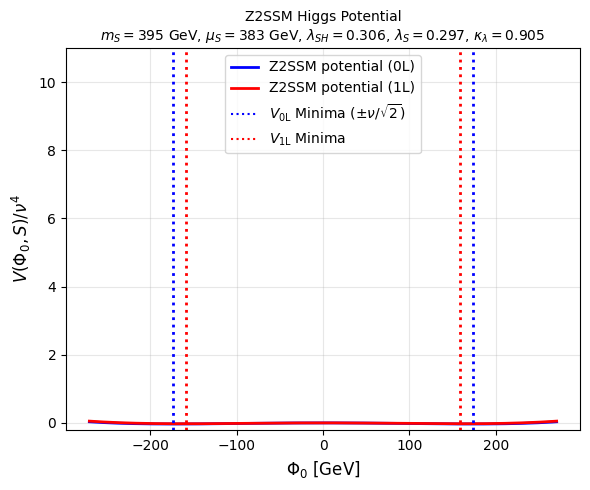

In [78]:
# mS_test = 500
# muS_test = 400
# lamS_test = 2
# lamSH_test = 2*(mS_test**2 - muS_test**2)/vev**2
BP_slice = [0, 1, 2, 3, 5]
muS_test = muS[BP_slice]
lamS_test = lamS[BP_slice]
lamSH_test = lamSH[BP_slice]
mS_test = mS[BP_slice]
Z2SSM = EFT_matching.Z2SSM(muS=muS_test, lamS=lamS_test, lamSH=lamSH_test)

if not np.ndim(muS_test)==0:
    animation_parameter_points=True
else:
    animation_parameter_points=False
loop_order=["0L", "1L"]; loop_order_txt = "0L_1L"
plot_kwargs={}
plot_kwargs["0L"] = {"lw":2, "color":"blue",}
plot_kwargs["1L"] = {"lw":2, "color":"red",}

fig, ax, ani = Z2SSM.plot_higgs_potential_Z2SSM_projection(
    # phi_range=(-200, 200),
    V_range=(-0.2, 11),
    plot_dir=plot_dir, 
    figsize=(6,5),
    interval=2000,
    loop_order=loop_order,
    loop_order_txt=loop_order_txt,
    plot_kwargs=plot_kwargs,
    plot_1L_minima=True,
    legend_kwargs={"loc": "upper center", "fontsize": 10},
)
# fig, ax, ani, frames = Z2SSM.plot_higgs_potential_Z2SSM(animation=False, plot_dir=plot_dir)
if animation_parameter_points:
    HTML_anim = HTML(f'<div style="width:600px; height:600px;">{ani.to_jshtml()}</div>')
    display(HTML_anim)
    ani.save(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM_parameter_points.gif")
else:
    fig.savefig(f"{plot_dir}/Higgs_potential_{loop_order_txt}_Z2SSM.pdf")